# Red Wine Dataset Practice

## Section 1: Data View & Wrangling
Topics Covered:
- How to x
- How to y
- Z then A

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
np.random.seed(42)

### Load & Explore The Data

In [2]:
df = pd.read_csv('data/winequality-red.csv') # Read in from CSV

df.head() # Display the first few rows

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info() # Useful for checking non-null values, making sure features have same count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.shape # Make sure its a 2D array

(1599, 12)

In [5]:
# df_reshaped = df.values.reshape(-1, df.shape[1]) # Reshape to 2D array if needed
df.describe() # Statistical values for each column

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df.isnull().sum() # Another way to check for null values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
# IMPORTANT -  We dont need to drop rows with missing unimportant values
# For example - If we are using pH & the 'acidic' columns we only care about tidying their data
# So if alcohol had null/na values but the other ones were populated in a row we could still use it
df_clean = df.dropna(subset=['pH']) # And this is how you drop null values rows specified by column

feature_columns_example = ['pH', 'fixed acidity', 'volatile acidity', 'citric acid'] # Select features
X = df_clean[feature_columns_example]
y = df_clean['free sulfur dioxide']

print(f"Dataset shape: {X.shape}")
# print(f"Number of classes: {y.nunique()}") # If we were classifying something like species or type 
# print(f"Class distribution:\n{y.value_counts()}") # We would set that as our target and could use these to check distrib

Dataset shape: (1599, 4)


In [8]:
X.describe()

,pH,fixed acidity,volatile acidity,citric acid
count,1599.000000,1599.000000,1599.000000,1599.000000
mean,3.311113,8.319637,0.527821,0.270976
std,0.154386,1.741096,0.179060,0.194801
min,2.740000,4.600000,0.120000,0.000000
25%,3.210000,7.100000,0.390000,0.090000
50%,3.310000,7.900000,0.520000,0.260000
75%,3.400000,9.200000,0.640000,0.420000
max,4.010000,15.900000,1.580000,1.000000


#### Feature Selection

In [9]:
df['quality'].value_counts() # We want to predict what the quality of the wine will be

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

<Axes: >

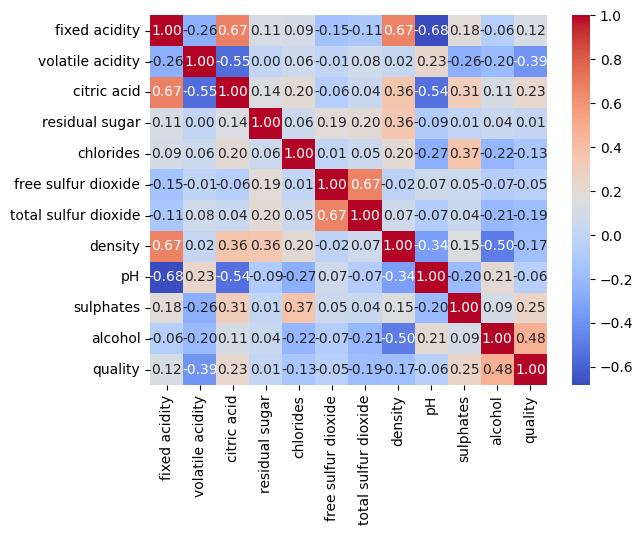

In [10]:
# Can be used for feature selection look for values in this example 'quality'
# Any value far away from 0 positive or negative has strong correlation
# From this we can see alcohol(0.48), volatileacidity(-0.39) & sulphates(0.25)
# Are the 3 strongest correlations so we can pick those
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [11]:
# Select the top correlated features identified from heatmap
feature_columns = ['alcohol', 'volatile acidity', 'sulphates']
X = df[feature_columns]
y = df['quality']

# Bin quality scores into 3 classes to simplify the problem (give better accuracy scores)
# Low: 3-4, Medium: 5-6, High: 7-8
y = y.map(lambda q: 'low' if q <= 4 else ('high' if q >= 7 else 'medium'))

print(f"Features: {feature_columns}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Features: ['alcohol', 'volatile acidity', 'sulphates']
X shape: (1599, 3)
y distribution:
quality
medium    1319
high       217
low         63
Name: count, dtype: int64


### Visualisation & EDA

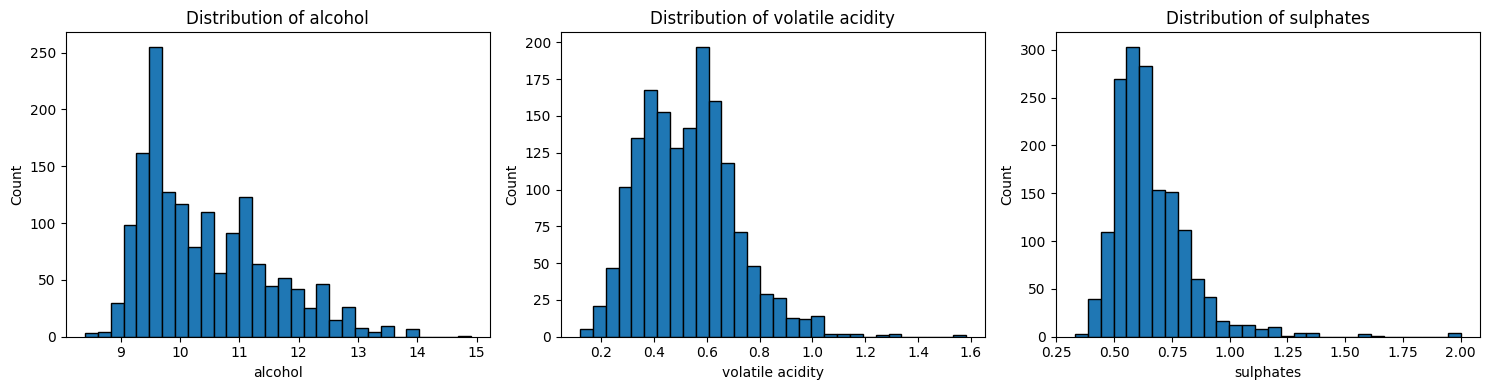

In [12]:
# Visualise distribution of each selected feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(feature_columns):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

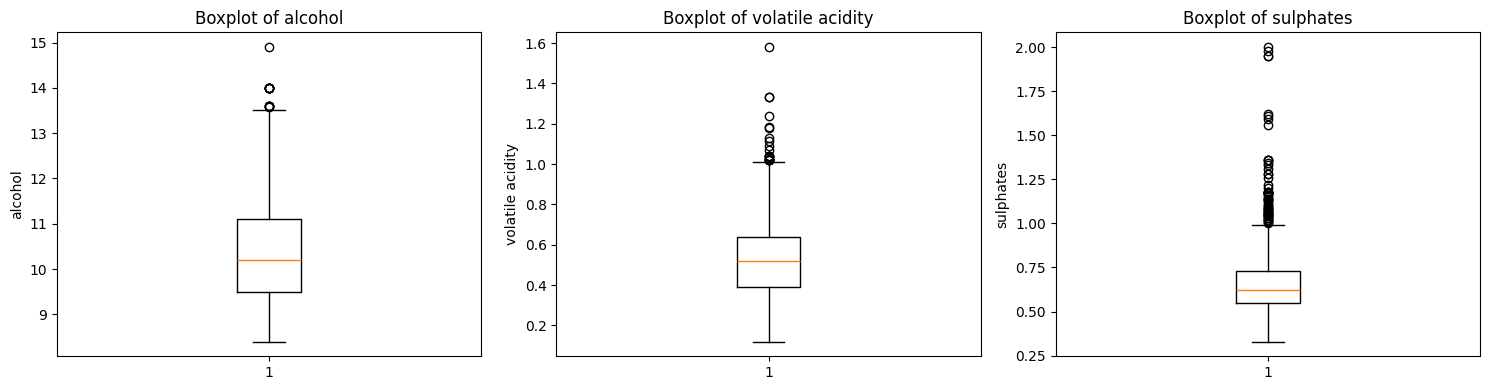

In [13]:
# Boxplots help visualise outliers - dots outside the whiskers are potential outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(feature_columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

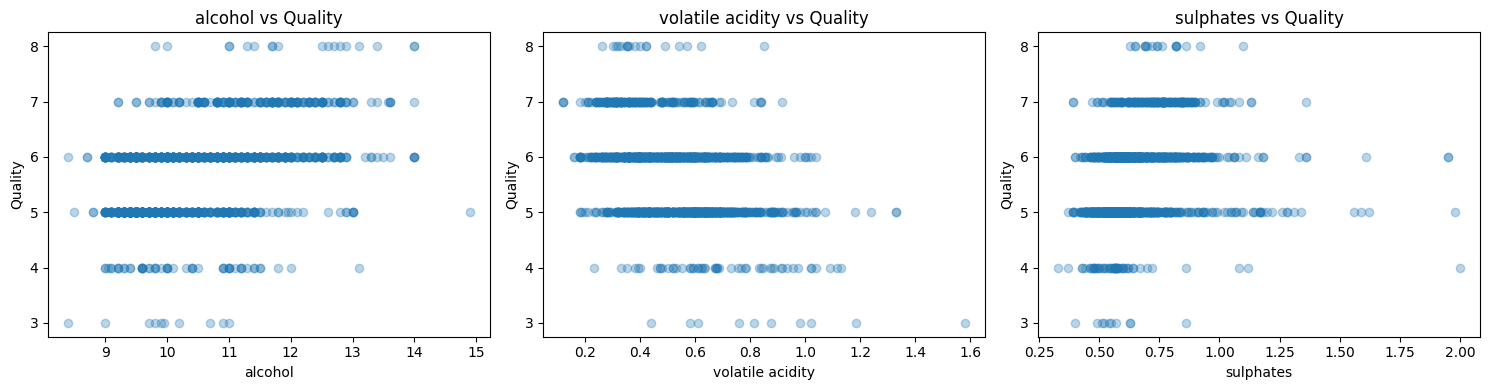

In [14]:
# Visualise how each feature relates to quality
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(feature_columns):
    axes[i].scatter(df[col], df['quality'], alpha=0.3)
    axes[i].set_title(f'{col} vs Quality')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Quality')

plt.tight_layout()
plt.show()

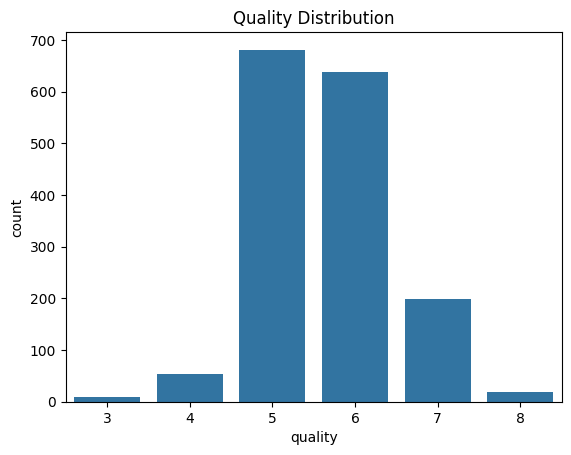

In [15]:
# Check class imbalance in our target variable
# Important - if heavily imbalanced our model may be biased towards the majority class
sns.countplot(x='quality', data=df)
plt.title('Quality Distribution')
plt.show()

### Preprocessing

In [16]:
# Standard 80/20 train/test split
# stratify=y ensures class distribution is preserved in both splits - important given quality 5/6 dominate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1279, 3)
X_test shape: (320, 3)


In [17]:
# Three way split - train, test, validation
# IMPORTANT:
# - Test set is used during model evaluation & hyperparameter tuning
# - Validation set is held back until the VERY END to give a final unbiased accuracy score
# - Never tune your model based on validation results, it defeats the purpose

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (959, 3)
X_test shape: (320, 3)
X_val shape: (320, 3)


### Models

#### Logistic Regression

In [18]:
# Logistic Regression pipeline - StandardScaler ensures features are on the same scale
# Important for LR as it uses gradient descent which is sensitive to feature scale
lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# Cross validate - gives us a more reliable accuracy score than a single train/test split
# cv=5 means 5 fold cross validation, splits data into 5 parts and trains/tests 5 times
lr_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5)
print(f"Logistic Regression CV scores: {lr_scores}")
print(f"Mean accuracy: {lr_scores.mean():.3f} (+/- {lr_scores.std():.3f})")

Logistic Regression CV scores: [0.83333333 0.82291667 0.84375    0.8125     0.84293194]
Mean accuracy: 0.831 (+/- 0.012)


In [ ]:
# C is the regularisation parameter - smaller C = more regularisation = simpler model
# Too small = underfitting, too large = overfitting
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best C: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

Best C: {'logisticregression__C': 10}
Best CV accuracy: 0.833


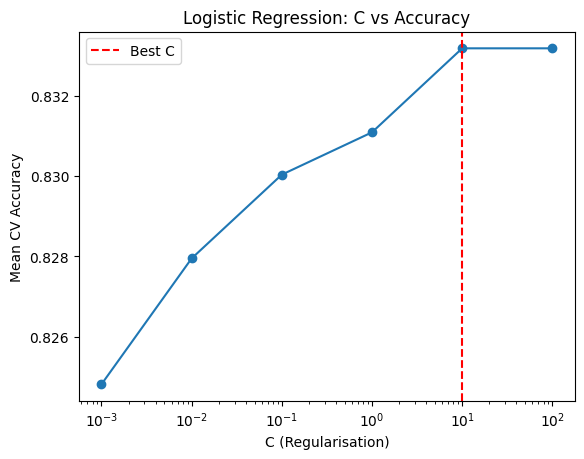

In [20]:
# Plot how accuracy changes with C to see where overfitting begins
c_values = param_grid['logisticregression__C']
mean_scores = grid_search.cv_results_['mean_test_score']

plt.plot(c_values, mean_scores, marker='o')
plt.xscale('log') # Log scale as C values span several orders of magnitude
plt.xlabel('C (Regularisation)')
plt.ylabel('Mean CV Accuracy')
plt.title('Logistic Regression: C vs Accuracy')
plt.axvline(grid_search.best_params_['logisticregression__C'], 
            color='red', linestyle='--', label='Best C')
plt.legend()
plt.show()

# After the red line the model starts to overfit - it is too closely fitting the training data
# and will perform worse on unseen data

              precision    recall  f1-score   support

        high       0.53      0.23      0.32        43
         low       0.00      0.00      0.00        13
      medium       0.85      0.96      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.40      0.41       320
weighted avg       0.77      0.82      0.78       320



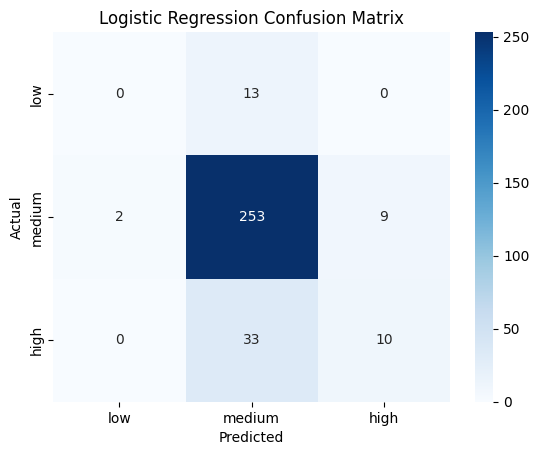

Logistic Regression Test Accuracy: 0.822


In [ ]:
# Fit best model and evaluate on TEST set
# IMPORTANT - we are using X_test here not X_val
# X_val is held back until the very end for final unbiased accuracy comparison across all models
best_lr = grid_search.best_estimator_
best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

# Plot confusion matrix as a heatmap
cm = confusion_matrix(y_test, y_pred_lr, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {lr_accuracy:.3f}")

The reason we arent getting amazing accuracies is because 'quality' is quite subjective two humans couldve graded wines of similar composition on completely different ends.

#### KNN (K-Nearest Neighbors)

In [22]:
# KNN pipeline - StandardScaler is especially important for KNN
# KNN uses distance between points, if features are on different scales it will be biased towards larger ones
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())

knn_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5)
print(f"KNN CV scores: {knn_scores}")
print(f"Mean accuracy: {knn_scores.mean():.3f} (+/- {knn_scores.std():.3f})")

KNN CV scores: [0.828125   0.78645833 0.8125     0.81770833 0.84293194]
Mean accuracy: 0.818 (+/- 0.019)


In [ ]:
# n_neighbors is the key hyperparameter for KNN
# Too small = overfitting (too sensitive to individual points)
# Too large = underfitting (too generalised)
param_grid = {'kneighborsclassifier__n_neighbors': range(1, 21)}

grid_search_knn = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

print(f"Best K: {grid_search_knn.best_params_}")
print(f"Best CV accuracy: {grid_search_knn.best_score_:.3f}")

Best K: {'kneighborsclassifier__n_neighbors': 19}
Best CV accuracy: 0.839


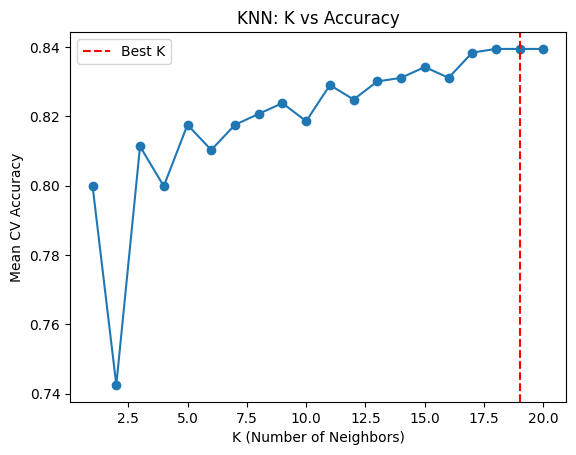

In [24]:
k_values = list(range(1, 21))
mean_scores = grid_search_knn.cv_results_['mean_test_score']

plt.plot(k_values, mean_scores, marker='o')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN: K vs Accuracy')
plt.axvline(grid_search_knn.best_params_['kneighborsclassifier__n_neighbors'],
            color='red', linestyle='--', label='Best K')
plt.legend()
plt.show()

# Low K values on the left of the red line = overfitting, model is too sensitive to individual points
# Higher K values smooth out the decision boundary but can start to underfit

              precision    recall  f1-score   support

        high       0.63      0.28      0.39        43
         low       0.00      0.00      0.00        13
      medium       0.85      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.49      0.42      0.43       320
weighted avg       0.79      0.84      0.80       320



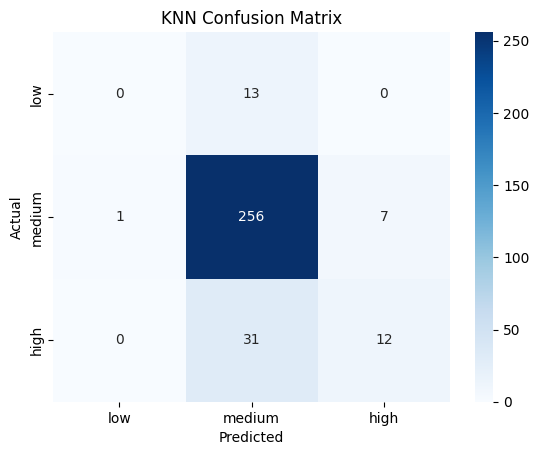

KNN Test Accuracy: 0.838


In [25]:
best_knn = grid_search_knn.best_estimator_
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Test Accuracy: {knn_accuracy:.3f}")

#### Decision Tree

In [26]:
# Decision Trees don't require scaling but we include it in the pipeline for consistency
dt_pipeline = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42))

dt_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=5)
print(f"Decision Tree CV scores: {dt_scores}")
print(f"Mean accuracy: {dt_scores.mean():.3f} (+/- {dt_scores.std():.3f})")

Decision Tree CV scores: [0.75       0.765625   0.78645833 0.76041667 0.85340314]
Mean accuracy: 0.783 (+/- 0.037)


In [27]:
# max_depth controls how deep the tree can grow
# Too deep = overfitting (memorises training data), too shallow = underfitting
# Other useful params: min_samples_split, min_samples_leaf - also control complexity
param_grid = {'decisiontreeclassifier__max_depth': range(1, 21)}

grid_search_dt = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

print(f"Best max_depth: {grid_search_dt.best_params_}")
print(f"Best CV accuracy: {grid_search_dt.best_score_:.3f}")

Best max_depth: {'decisiontreeclassifier__max_depth': 2}
Best CV accuracy: 0.833


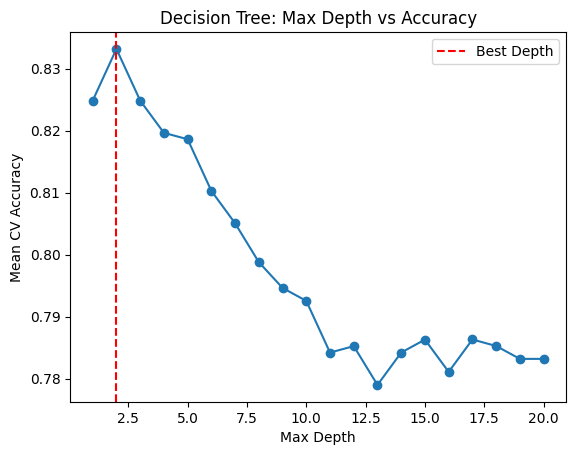

In [28]:
depth_values = list(range(1, 21))
mean_scores = grid_search_dt.cv_results_['mean_test_score']

plt.plot(depth_values, mean_scores, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Mean CV Accuracy')
plt.title('Decision Tree: Max Depth vs Accuracy')
plt.axvline(grid_search_dt.best_params_['decisiontreeclassifier__max_depth'],
            color='red', linestyle='--', label='Best Depth')
plt.legend()
plt.show()

# Beyond the red line the tree is too deep and starts memorising training data (overfitting)

              precision    recall  f1-score   support

        high       0.62      0.47      0.53        43
         low       0.00      0.00      0.00        13
      medium       0.87      0.94      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.47      0.48       320
weighted avg       0.80      0.84      0.82       320



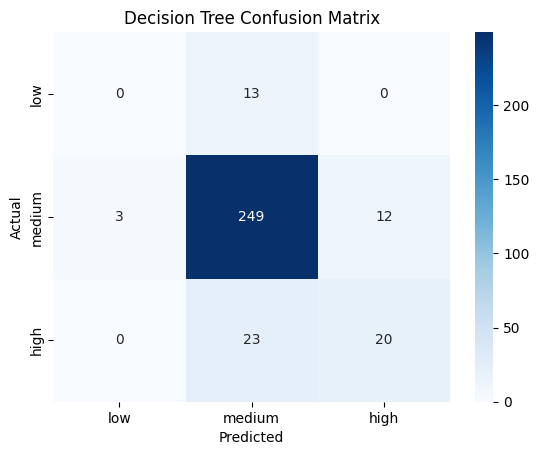

Decision Tree Test Accuracy: 0.841


In [30]:
best_dt = grid_search_dt.best_estimator_
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {dt_accuracy:.3f}")

#### SVM (Support Vector Machine)

In [31]:
# SVM pipeline - StandardScaler is important for SVM
# SVM finds the best boundary between classes, sensitive to feature scale
svm_pipeline = make_pipeline(StandardScaler(), SVC(random_state=42))

svm_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5)
print(f"SVM CV scores: {svm_scores}")
print(f"Mean accuracy: {svm_scores.mean():.3f} (+/- {svm_scores.std():.3f})")

SVM CV scores: [0.85416667 0.81770833 0.85416667 0.82291667 0.83769634]
Mean accuracy: 0.837 (+/- 0.015)


In [32]:
# C is the regularisation parameter - same concept as Logistic Regression
# kernel determines the shape of the decision boundary
# rbf (radial basis function) handles non-linear boundaries, linear draws a straight line
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 100],
              'svc__kernel': ['linear', 'rbf']}

grid_search_svm = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

print(f"Best params: {grid_search_svm.best_params_}")
print(f"Best CV accuracy: {grid_search_svm.best_score_:.3f}")

Best params: {'svc__C': 1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.837


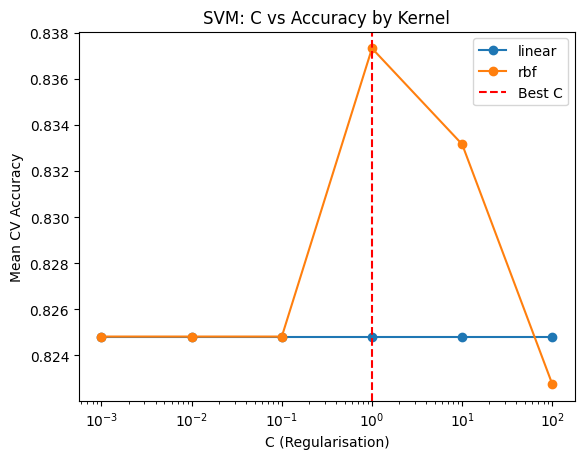

In [33]:
for kernel in ['linear', 'rbf']:
    mask = [r['svc__kernel'] == kernel for r in grid_search_svm.cv_results_['params']]
    scores = [s for s, m in zip(grid_search_svm.cv_results_['mean_test_score'], mask) if m]
    plt.plot([0.001, 0.01, 0.1, 1, 10, 100], scores, marker='o', label=kernel)

plt.xscale('log')
plt.xlabel('C (Regularisation)')
plt.ylabel('Mean CV Accuracy')
plt.title('SVM: C vs Accuracy by Kernel')
plt.axvline(grid_search_svm.best_params_['svc__C'], color='red', linestyle='--', label='Best C')
plt.legend()
plt.show()

              precision    recall  f1-score   support

        high       0.60      0.21      0.31        43
         low       0.00      0.00      0.00        13
      medium       0.85      0.97      0.90       264

    accuracy                           0.83       320
   macro avg       0.48      0.39      0.41       320
weighted avg       0.78      0.83      0.79       320



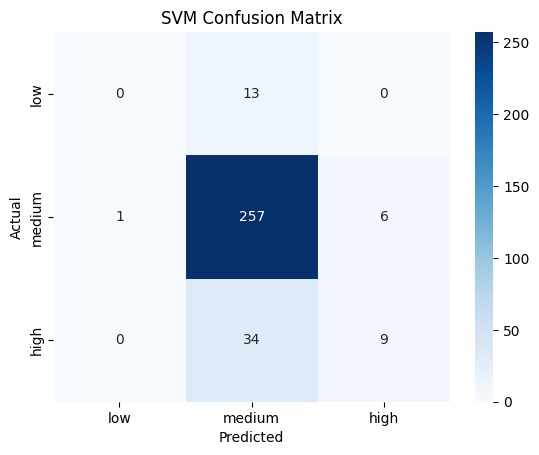

SVM Test Accuracy: 0.831


In [34]:
best_svm = grid_search_svm.best_estimator_
best_svm.fit(X_train, y_train)
y_pred_svm = best_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Test Accuracy: {svm_accuracy:.3f}")

#### Gaussian Naive Bayes

In [35]:
# GaussianNB doesn't require scaling but we include it for consistency
# Naive Bayes assumes all features are independent of each other - rarely true but works well in practice
gnb_pipeline = make_pipeline(StandardScaler(), GaussianNB())

gnb_scores = cross_val_score(gnb_pipeline, X_train, y_train, cv=5)
print(f"GaussianNB CV scores: {gnb_scores}")
print(f"Mean accuracy: {gnb_scores.mean():.3f} (+/- {gnb_scores.std():.3f})")

GaussianNB CV scores: [0.80208333 0.81770833 0.859375   0.82291667 0.82198953]
Mean accuracy: 0.825 (+/- 0.019)


In [36]:
# var_smoothing adds a small value to variance to avoid zero probabilities
# Too small = unstable, too large = oversimplified
param_grid = {'gaussiannb__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]}

grid_search_gnb = GridSearchCV(gnb_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_gnb.fit(X_train, y_train)

print(f"Best params: {grid_search_gnb.best_params_}")
print(f"Best CV accuracy: {grid_search_gnb.best_score_:.3f}")

Best params: {'gaussiannb__var_smoothing': 1e-11}
Best CV accuracy: 0.825


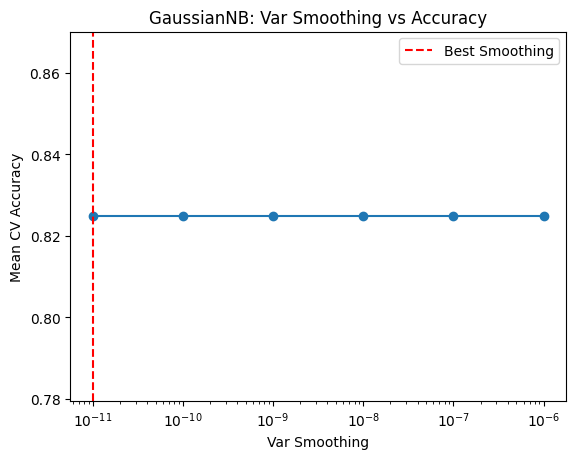

In [37]:
smoothing_values = [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
mean_scores = grid_search_gnb.cv_results_['mean_test_score']

plt.plot(smoothing_values, mean_scores, marker='o')
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Mean CV Accuracy')
plt.title('GaussianNB: Var Smoothing vs Accuracy')
plt.axvline(grid_search_gnb.best_params_['gaussiannb__var_smoothing'],
            color='red', linestyle='--', label='Best Smoothing')
plt.legend()
plt.show()

              precision    recall  f1-score   support

        high       0.52      0.37      0.43        43
         low       0.00      0.00      0.00        13
      medium       0.86      0.91      0.88       264

    accuracy                           0.80       320
   macro avg       0.46      0.43      0.44       320
weighted avg       0.78      0.80      0.78       320



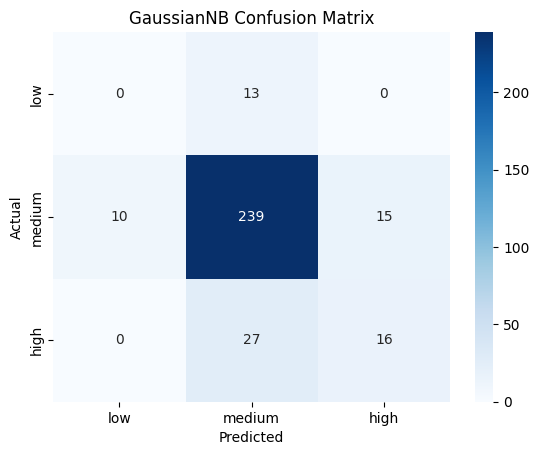

GaussianNB Test Accuracy: 0.797


In [38]:
best_gnb = grid_search_gnb.best_estimator_
best_gnb.fit(X_train, y_train)
y_pred_gnb = best_gnb.predict(X_test)

print(classification_report(y_test, y_pred_gnb))

cm = confusion_matrix(y_test, y_pred_gnb, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title('GaussianNB Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
print(f"GaussianNB Test Accuracy: {gnb_accuracy:.3f}")

### Final Eval & Compare

               Model  Test Accuracy
       Decision Tree       0.840625
                 KNN       0.837500
                 SVM       0.831250
 Logistic Regression       0.821875
Gaussian Naive Bayes       0.796875


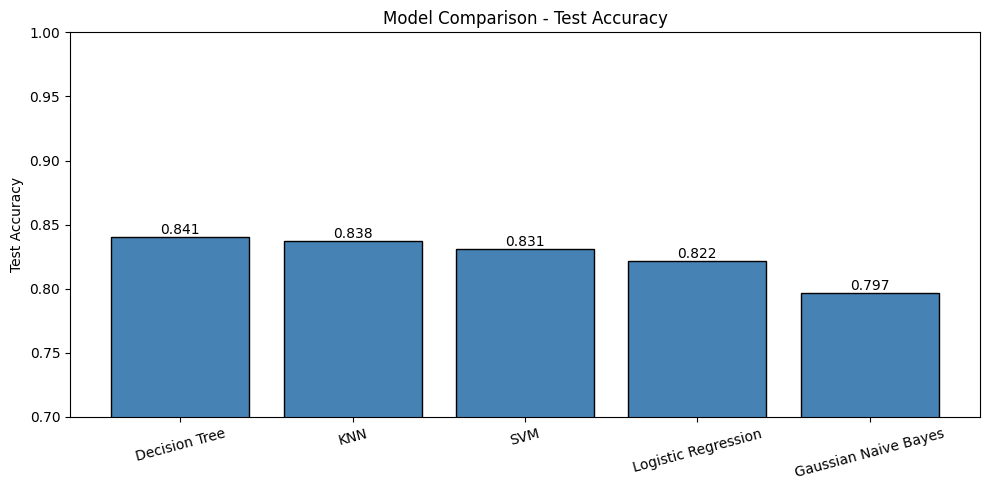

In [39]:
results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM', 'Gaussian Naive Bayes'],
    'Test Accuracy': [lr_accuracy, knn_accuracy, dt_accuracy, svm_accuracy, gnb_accuracy]
}

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Test Accuracy'], color='steelblue', edgecolor='black')
plt.ylim(0.7, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.xticks(rotation=15)

for i, acc in enumerate(results_df['Test Accuracy']):
    plt.text(i, acc + 0.002, f'{acc:.3f}', ha='center')

plt.tight_layout()
plt.show()

Best model: Decision Tree
              precision    recall  f1-score   support

        high       0.52      0.34      0.41        44
         low       0.25      0.08      0.12        12
      medium       0.86      0.94      0.90       264

    accuracy                           0.82       320
   macro avg       0.54      0.45      0.48       320
weighted avg       0.79      0.82      0.80       320



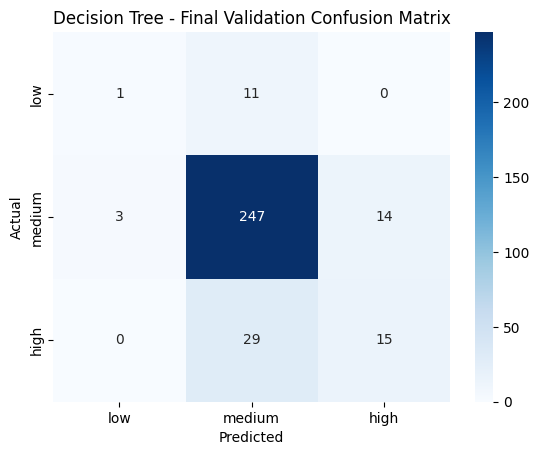

Test Accuracy:       0.841
Validation Accuracy: 0.822
Difference:          0.019


In [40]:
# Run the best performing model against X_val for a final unbiased accuracy score
# IMPORTANT - this is the only time we use X_val, we have never touched it until now
# This gives us a true measure of how well our model generalises to completely unseen data

best_model_name = results_df.iloc[0]['Model']
best_model = {'Logistic Regression': best_lr, 'KNN': best_knn, 
              'Decision Tree': best_dt, 'SVM': best_svm, 
              'Gaussian Naive Bayes': best_gnb}[best_model_name]

print(f"Best model: {best_model_name}")

y_pred_val = best_model.predict(X_val)

print(classification_report(y_val, y_pred_val))

cm = confusion_matrix(y_val, y_pred_val, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low', 'medium', 'high'], yticklabels=['low', 'medium', 'high'])
plt.title(f'{best_model_name} - Final Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"Test Accuracy:       {results_df.iloc[0]['Test Accuracy']:.3f}")
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Difference:          {abs(results_df.iloc[0]['Test Accuracy'] - val_accuracy):.3f}")
# A small difference means the model is generalising well to unseen data
# A large difference suggests the model was overfit to the test set